# Missingness Correlation Analysis

This notebook analyzes correlations between missing value patterns across columns in the Knee Replacement Provider dataset.

**Goal:** Identify which columns tend to have missing values together (systematic patterns) vs. independently.

In [31]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print('Libraries imported successfully.')

Libraries imported successfully.


In [37]:
# Load the prepared parquet file from Step 1
import os

# Get the current notebook directory
notebook_dir = Path.cwd()
print(f"Current working directory: {notebook_dir}")

# Use relative path from the Data-prepare folder to the output folder
parquet_path = Path(r"..") / "output" / "knee_replacement_providerStep1.parquet"

# Resolve to absolute path
parquet_path_abs = parquet_path.resolve()
print(f"Looking for parquet file at: {parquet_path_abs}")

# Check if file exists
if not parquet_path_abs.exists():
	print(f"File not found at: {parquet_path_abs}")
	# Try alternative path
	alt_path = Path(r"..\output\knee_replacement_providerStep1.parquet").resolve()
	print(f"Trying alternative path: {alt_path}")
	if alt_path.exists():
		parquet_path_abs = alt_path
	else:
		print("Please verify the path is correct.")

if parquet_path_abs.exists():
	df = pl.read_parquet(parquet_path_abs)
	print(f"\n✓ Successfully loaded dataset from: {parquet_path_abs}")
	print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Current working directory: c:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\Data-prepare
Looking for parquet file at: C:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\output\knee_replacement_providerStep1.parquet

✓ Successfully loaded dataset from: C:\Users\GinoH\OneDrive - SGB SMIT Group\Documents\GitHub\EAISI-NHS\notebooks\Lalita\UnderstandingData\output\knee_replacement_providerStep1.parquet
Shape: 139,236 rows × 82 columns


In [38]:
# Define missing value sentinels (same as in Step 1)
MISSING_SENTINELS_STR = {'*', ''}
MISSING_SENTINELS_NUM = {999, 9}

# Verify df is loaded
if 'df' not in dir():
    print("Error: df not found. Please run the cell that loads the parquet file first.")
else:
    # Convert Polars DataFrame to Pandas for analysis
    df_pd = df.to_pandas()

    # Build binary missingness indicator matrix (1 = missing, 0 = present)
    def is_missing_np(series: pl.Series) -> np.ndarray:
        if series.dtype in (pl.Utf8, pl.String):
            return (series.is_null() | series.is_in(list(MISSING_SENTINELS_STR))).to_numpy().astype(np.uint8)
        else:
            return (series.is_null() | series.is_in(list(MISSING_SENTINELS_NUM))).to_numpy().astype(np.uint8)

    col_names = [c for c in df.columns if c != "has_missing"]
    miss_matrix = np.column_stack([is_missing_np(df[c]) for c in col_names])

    print(f"Missingness matrix created: {miss_matrix.shape[0]:,} rows × {miss_matrix.shape[1]} columns")
    print(f"Missing value indicators: 0 = present, 1 = missing")

Missingness matrix created: 139,236 rows × 82 columns
Missing value indicators: 0 = present, 1 = missing


In [39]:
# Create a DataFrame where each column represents missingness (1 = missing, 0 = present)
missingness_df = pd.DataFrame(miss_matrix, columns=col_names)

# Calculate Pearson correlation matrix between missingness patterns
missingness_corr = missingness_df.corr()

print('=== Missingness Correlation Matrix (Column-to-Column) ===')
print('(1.0 = always missing together; 0 = no pattern; -1 = one missing when other present)\n')

# Show the full correlation matrix
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missingness_corr.round(3))

=== Missingness Correlation Matrix (Column-to-Column) ===
(1.0 = always missing together; 0 = no pattern; -1 = one missing when other present)

                                                  Provider Code  Procedure  \
Provider Code                                               NaN        NaN   
Procedure                                                   NaN        NaN   
Revision Flag                                               NaN        NaN   
Year                                                        NaN        NaN   
Age Band                                                    NaN        NaN   
Gender                                                      NaN        NaN   
Pre-Op Q Assisted                                           NaN        NaN   
Pre-Op Q Assisted By                                        NaN        NaN   
Pre-Op Q Symptom Period                                     NaN        NaN   
Pre-Op Q Previous Surgery                                   NaN        NaN  

In [40]:
# Identify strong correlations (> 0.3 or < -0.3, excluding diagonal)
strong_correlations = []
for i in range(len(missingness_corr.columns)):
    for j in range(i+1, len(missingness_corr.columns)):
        corr_val = missingness_corr.iloc[i, j]
        if abs(corr_val) > 0.3:
            strong_correlations.append({
                'Column 1': missingness_corr.columns[i],
                'Column 2': missingness_corr.columns[j],
                'Correlation': round(corr_val, 3)
            })

strong_corr_df = pd.DataFrame(strong_correlations).sort_values('Correlation', key=abs, ascending=False)

print('\n=== Strong Correlations (|r| > 0.3) Between Missing Values ===')
if len(strong_corr_df) > 0:
    print(f"Found {len(strong_corr_df)} strong correlations:\n")
    print(strong_corr_df.to_string(index=False))
else:
    print('No strong correlations found between missingness patterns.')


=== Strong Correlations (|r| > 0.3) Between Missing Values ===
Found 241 strong correlations:

                                        Column 1                                         Column 2  Correlation
                                        Age Band                                           Gender        1.000
            Knee Replacement Pre-Op Q Night Pain                   Knee Replacement Pre-Op Q Work        0.962
            Knee Replacement Pre-Op Q Night Pain             Knee Replacement Pre-Op Q Confidence        0.960
              Knee Replacement Pre-Op Q Shopping                 Knee Replacement Pre-Op Q Stairs        0.959
            Knee Replacement Pre-Op Q Night Pain               Knee Replacement Pre-Op Q Shopping        0.957
            Knee Replacement Pre-Op Q Night Pain                 Knee Replacement Pre-Op Q Stairs        0.957
            Knee Replacement Pre-Op Q Confidence               Knee Replacement Pre-Op Q Shopping        0.956
               K

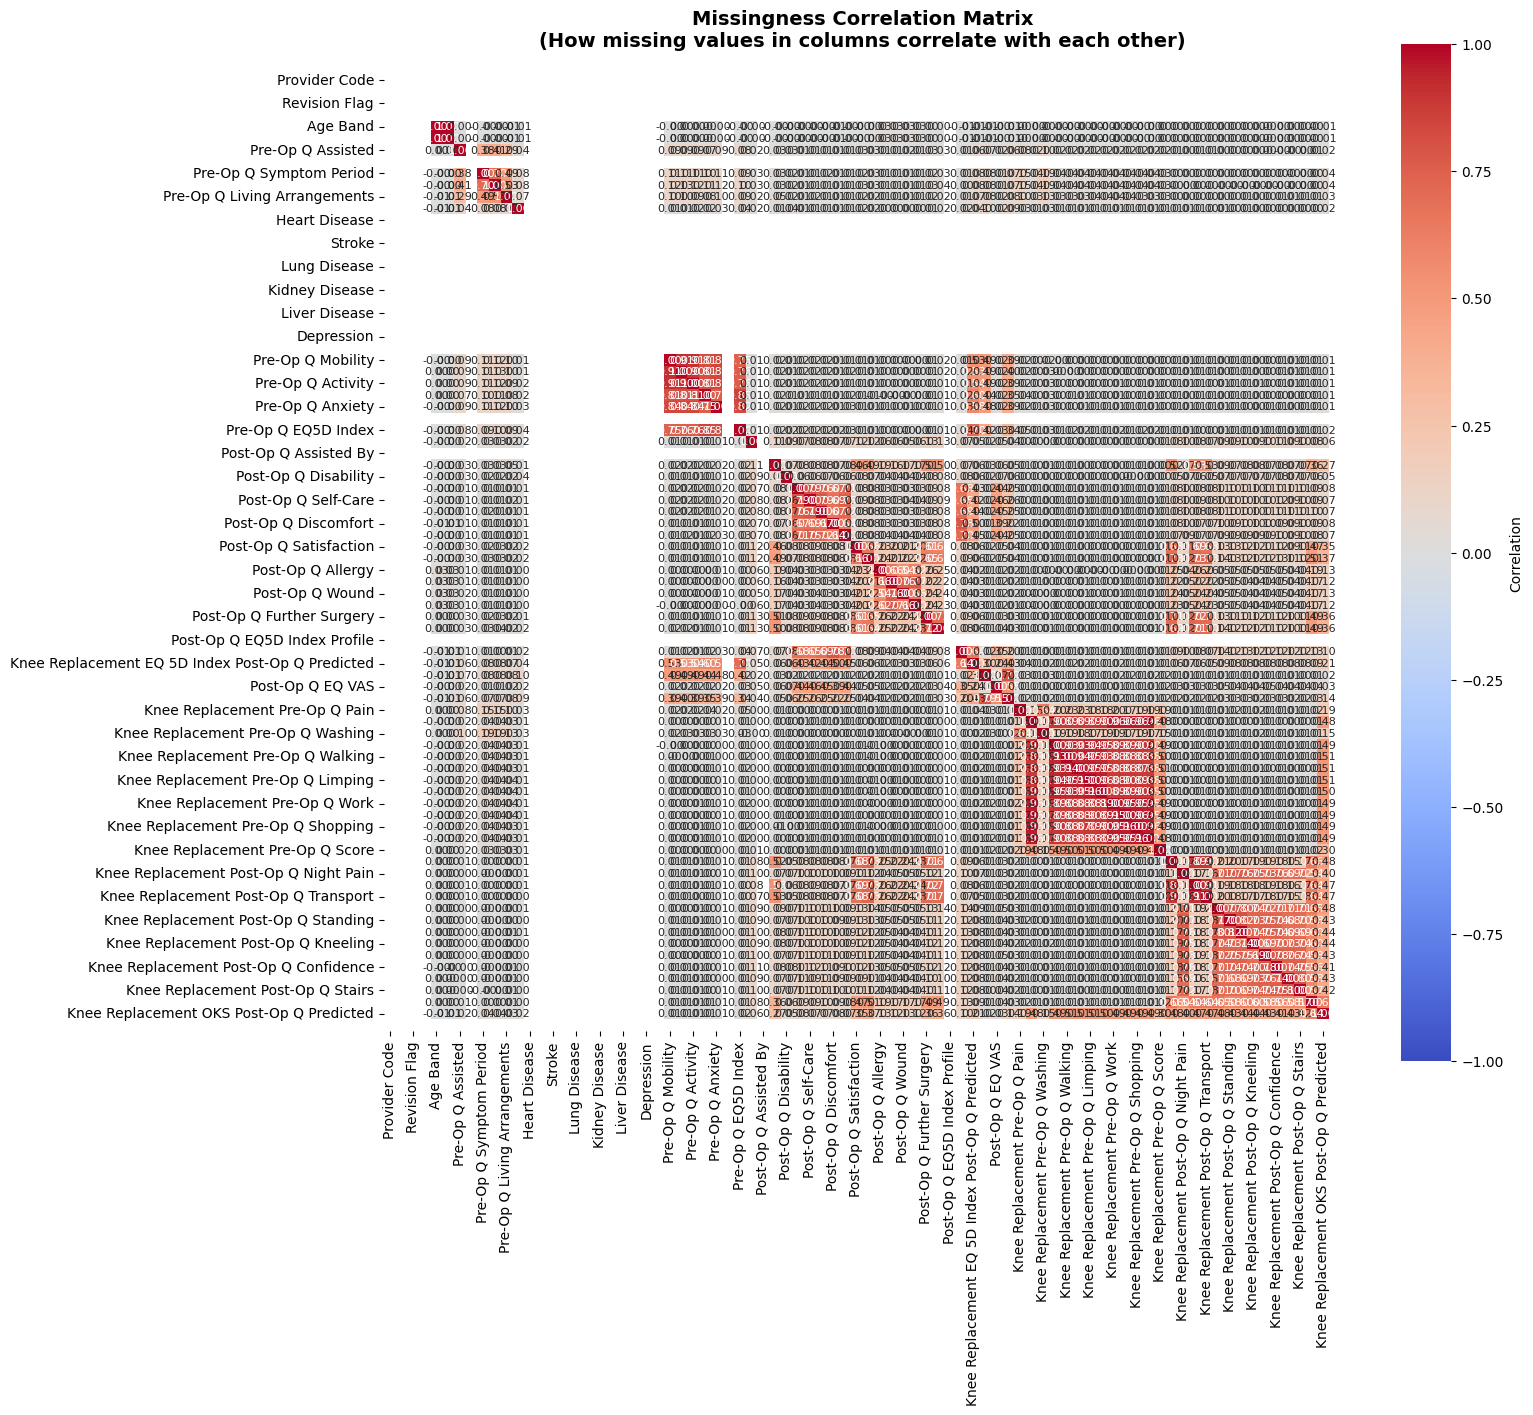

Heatmap saved as missingness_correlation_heatmap.png


In [43]:
# Visualize the correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(missingness_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})

ax.set_title('Missingness Correlation Matrix\n(How missing values in columns correlate with each other)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('missingness_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Heatmap saved as missingness_correlation_heatmap.png')

In [44]:
# Summary statistics
print('\n=== Summary Statistics ===')
print(f'Total column pairs analyzed: {len(missingness_corr) * (len(missingness_corr) - 1) // 2}')
print(f'Strong positive correlations (r > 0.3): {len(strong_corr_df[strong_corr_df["Correlation"] > 0.3])}')
print(f'Strong negative correlations (r < -0.3): {len(strong_corr_df[strong_corr_df["Correlation"] < -0.3])}')
print(f'Average absolute correlation: {missingness_corr.values[np.triu_indices_from(missingness_corr.values, k=1)].mean():.3f}')


=== Summary Statistics ===
Total column pairs analyzed: 3321
Strong positive correlations (r > 0.3): 241
Strong negative correlations (r < -0.3): 0
Average absolute correlation: nan


In [45]:
# Interpretation guide
print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("""
HIGH POSITIVE CORRELATIONS (r > 0.5):
  → These columns are almost always missing together
  → Suggests a common cause (e.g., data collection system, suppression rules)
  → Consider imputing them together or dropping them as a group

MODERATE POSITIVE CORRELATIONS (0.3 < r ≤ 0.5):
  → These columns often (but not always) miss together
  → May indicate related fields with partial overlap in missingness

NO CORRELATION (r ≈ 0):
  → Missingness patterns are independent
  → Missing values in one column don't predict missing in another
  → Safe to impute individually

NEGATIVE CORRELATIONS (r < -0.3):
  → When one column is missing, the other tends to be present
  → May indicate complementary data entry or different questionnaire routes
  → Consider this pattern when imputing
""")
print("="*80)


INTERPRETATION GUIDE

HIGH POSITIVE CORRELATIONS (r > 0.5):
  → These columns are almost always missing together
  → Suggests a common cause (e.g., data collection system, suppression rules)
  → Consider imputing them together or dropping them as a group

MODERATE POSITIVE CORRELATIONS (0.3 < r ≤ 0.5):
  → These columns often (but not always) miss together
  → May indicate related fields with partial overlap in missingness

NO CORRELATION (r ≈ 0):
  → Missingness patterns are independent
  → Missing values in one column don't predict missing in another
  → Safe to impute individually

NEGATIVE CORRELATIONS (r < -0.3):
  → When one column is missing, the other tends to be present
  → May indicate complementary data entry or different questionnaire routes
  → Consider this pattern when imputing



## Column Explanations

### Pre-operative (Pre-Op) Columns
These columns capture patient information and health status **before** knee replacement surgery:

- **Pre-Op Q Pain** - Pain level reported by patient before surgery
- **Pre-Op Q Night Pain** - Nighttime pain experienced before surgery
- **Pre-Op Q Washing** - Patient's ability to wash/bathe before surgery
- **Pre-Op Q Transport** - Patient's ability to use transportation before surgery
- **Pre-Op Q Work** - Patient's ability to work before surgery
- **Pre-Op Q Shopping** - Patient's ability to shop before surgery
- **Pre-Op Q Walking** - Patient's walking ability before surgery
- **Pre-Op Q Stairs** - Patient's ability to climb stairs before surgery
- **Pre-Op Q Standing** - Patient's ability to stand before surgery
- **Pre-Op Q Confidence** - Patient's confidence in joint before surgery
- **Pre-Op Q Kneeling** - Patient's ability to kneel before surgery
- **Pre-Op Q Limping** - Degree of limping before surgery
- **Pre-Op Q Score** - Composite Oxford Knee Score (sum of 12 items above)

- **Pre-Op Q Mobility** - EQ-5D dimension: Mobility problems
- **Pre-Op Q Self-Care** - EQ-5D dimension: Self-care limitations
- **Pre-Op Q Activity** - EQ-5D dimension: Usual activities limitations
- **Pre-Op Q Discomfort** - EQ-5D dimension: Pain/discomfort
- **Pre-Op Q Anxiety** - EQ-5D dimension: Anxiety/depression
- **Pre-Op Q EQ5D Index** - EQ-5D utility index (quality of life score)
- **Pre-Op Q EQ VAS** - EQ-5D visual analog scale (health rating 0-100)

- **Pre-Op Q Assisted** - Whether patient needed help completing questionnaire (0/1)
- **Pre-Op Q Assisted By** - Who assisted the patient (0/1)
- **Pre-Op Q Symptom Period** - Duration of symptoms before surgery
- **Pre-Op Q Previous Surgery** - Whether patient had previous surgery on same joint (0/1)
- **Pre-Op Q Living Arrangements** - Patient's living situation (1=with family, 2=alone, 3=nursing home, 4=other)
- **Pre-Op Q Disability** - Whether patient has long-term disability (0/1)

### Post-operative (Post-Op) Columns
These columns capture outcomes and patient status **after** knee replacement surgery:

- **Post-Op Q Pain** - Pain level reported after surgery
- **Post-Op Q Night Pain** - Nighttime pain after surgery
- **Post-Op Q Washing** - Ability to wash/bathe after surgery
- **Post-Op Q Transport** - Ability to use transportation after surgery
- **Post-Op Q Work** - Ability to work after surgery
- **Post-Op Q Shopping** - Ability to shop after surgery
- **Post-Op Q Walking** - Walking ability after surgery
- **Post-Op Q Stairs** - Ability to climb stairs after surgery
- **Post-Op Q Standing** - Ability to stand after surgery
- **Post-Op Q Confidence** - Confidence in joint after surgery
- **Post-Op Q Kneeling** - Ability to kneel after surgery
- **Post-Op Q Limping** - Degree of limping after surgery
- **Post-Op Q Score** - Composite Oxford Knee Score after surgery (TARGET/OUTCOME variable)

- **Post-Op Q Mobility** - EQ-5D dimension: Mobility after surgery
- **Post-Op Q Self-Care** - EQ-5D dimension: Self-care after surgery
- **Post-Op Q Activity** - EQ-5D dimension: Usual activities after surgery
- **Post-Op Q Discomfort** - EQ-5D dimension: Pain/discomfort after surgery
- **Post-Op Q Anxiety** - EQ-5D dimension: Anxiety/depression after surgery
- **Post-Op Q EQ5D Index** - EQ-5D utility index after surgery
- **Post-Op Q EQ VAS** - EQ-5D visual analog scale after surgery

- **Post-Op Q Assisted** - Whether patient needed help completing post-op questionnaire (0/1)
- **Post-Op Q Assisted By** - Who assisted patient post-op (0/1)
- **Post-Op Q Disability** - Post-operative disability status (0/1)

### Administrative Columns
- **Age Band** - Patient's age category (suppressed for confidentiality in some cases)
- **Gender** - Patient's gender (0=Unknown, 1=Male, 2=Female)
- **Revision Flag** - Whether the surgery was a revision procedure (0/1)
- **has_missing** - Indicator of whether the row has any missing values

### Key Outcome Variables
The **primary outcome variable** for predictive modeling is:
- **Post-Op Q Score** (Oxford Knee Score after surgery) - ranges 0-48, where higher scores indicate better outcomes

Secondary outcome measures:
- **Post-Op Q EQ5D Index** - Generic quality-of-life utility score (0-1 scale)
- **Post-Op Q EQ VAS** - Patient's visual rating of health (0-100 scale)

In [49]:
# ============================================================
# MISSINGNESS VS TARGET ANALYSIS
# Works with existing:
#   - df (Polars DataFrame)
#   - missingness_df (Pandas DataFrame with 1=missing, 0=present)
#   - col_names (list of feature names used in missingness_df)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.multitest import multipletests

# =========================
# CONFIGURATION
# =========================
TARGET_COL = "Knee Replacement Post-Op Q Score"   # <-- CHANGE THIS
TARGET_TYPE = "continuous"                   # options: "binary" or "continuous"

MIN_MISSING_COUNT = 10                   # skip columns with too few missing values
MIN_MISSING_PCT = 0.0                    # optional filter for final shortlist
MIN_EFFECT_SIZE = 0.02                   # practical threshold for shortlist
ALPHA = 0.05                             # significance level for FDR-adjusted p-values

# =========================
# CHECKS
# =========================
if "missingness_df" not in dir():
    raise ValueError("missingness_df not found. Please run your missingness matrix code first.")

if "col_names" not in dir():
    raise ValueError("col_names not found. Please run your missingness matrix code first.")

if "df" not in dir():
    raise ValueError("df not found. Please load your dataset first.")

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in df.columns")

if TARGET_TYPE not in ["binary", "continuous"]:
    raise ValueError("TARGET_TYPE must be either 'binary' or 'continuous'")

# =========================
# PREPARE ANALYSIS DATA
# =========================
analysis_df = missingness_df.copy()
analysis_df[TARGET_COL] = df[TARGET_COL].to_numpy()

# Drop rows where target itself is missing
analysis_df = analysis_df.loc[~pd.isna(analysis_df[TARGET_COL])].copy()

if TARGET_TYPE == "binary":
    unique_target_values = sorted(pd.Series(analysis_df[TARGET_COL]).dropna().unique().tolist())
    if len(unique_target_values) != 2:
        raise ValueError(
            f"Binary target expected exactly 2 unique values, but found: {unique_target_values}"
        )

print("=== Missingness vs Target Analysis ===")
print(f"Target column: {TARGET_COL}")
print(f"Target type:   {TARGET_TYPE}")
print(f"Rows used:     {len(analysis_df):,}")
print(f"Features tested: {len(col_names):,}")
print()

# =========================
# RUN ANALYSIS
# =========================
results = []

for col in col_names:
    if col not in analysis_df.columns:
        continue

    miss = analysis_df[col]
    y = analysis_df[TARGET_COL]

    # Skip columns with no variation in missingness
    if miss.nunique(dropna=True) < 2:
        continue

    missing_count = int((miss == 1).sum())
    present_count = int((miss == 0).sum())

    # Skip unstable very-rare missingness
    if missing_count < MIN_MISSING_COUNT:
        continue

    missing_pct = 100 * missing_count / len(analysis_df)

    y_missing = y[miss == 1]
    y_present = y[miss == 0]

    # Basic means
    mean_missing = y_missing.mean()
    mean_present = y_present.mean()
    difference = mean_missing - mean_present
    abs_difference = abs(difference)

    row = {
        "feature": col,
        "missing_count": missing_count,
        "present_count": present_count,
        "missing_pct": missing_pct,
        "target_mean_missing": mean_missing,
        "target_mean_present": mean_present,
        "difference": difference,
        "abs_difference": abs_difference,
        "p_value": np.nan,
        "test_used": None
    }

    # -------------------------
    # BINARY TARGET
    # -------------------------
    if TARGET_TYPE == "binary":
        contingency = pd.crosstab(miss, y)

        # Need a proper 2x2 table
        if contingency.shape == (2, 2):
            try:
                chi2, p_value, _, expected = chi2_contingency(contingency)

                # Optional effect size: Cramer's V for 2x2
                n = contingency.to_numpy().sum()
                cramer_v = np.sqrt(chi2 / n) if n > 0 else np.nan

                row["p_value"] = p_value
                row["test_used"] = "chi2"
                row["cramers_v"] = cramer_v

            except Exception:
                pass

    # -------------------------
    # CONTINUOUS TARGET
    # -------------------------
    elif TARGET_TYPE == "continuous":
        try:
            t_stat, p_value = ttest_ind(
                y_missing,
                y_present,
                equal_var=False,
                nan_policy="omit"
            )

            # Cohen's d (rough effect size)
            y_missing_clean = pd.Series(y_missing).dropna()
            y_present_clean = pd.Series(y_present).dropna()

            n1 = len(y_missing_clean)
            n2 = len(y_present_clean)

            if n1 > 1 and n2 > 1:
                s1 = y_missing_clean.std(ddof=1)
                s2 = y_present_clean.std(ddof=1)

                pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
                cohens_d = (mean_missing - mean_present) / pooled_sd if pooled_sd > 0 else np.nan
            else:
                cohens_d = np.nan

            row["p_value"] = p_value
            row["test_used"] = "welch_ttest"
            row["cohens_d"] = cohens_d

        except Exception:
            pass

    results.append(row)

# =========================
# BUILD RESULTS TABLE
# =========================
missing_vs_target_df = pd.DataFrame(results)

if missing_vs_target_df.empty:
    print("No valid features were available for testing.")
else:
    # Multiple testing correction
    valid_mask = missing_vs_target_df["p_value"].notna()

    if valid_mask.sum() > 0:
        reject, p_adj, _, _ = multipletests(
            missing_vs_target_df.loc[valid_mask, "p_value"],
            alpha=ALPHA,
            method="fdr_bh"
        )
        missing_vs_target_df.loc[valid_mask, "p_value_adj"] = p_adj
        missing_vs_target_df.loc[valid_mask, "significant_fdr"] = reject
    else:
        missing_vs_target_df["p_value_adj"] = np.nan
        missing_vs_target_df["significant_fdr"] = False

    missing_vs_target_df["significant_fdr"] = missing_vs_target_df["significant_fdr"].fillna(False)

    # Sort intelligently
    sort_cols = ["significant_fdr", "abs_difference", "missing_pct"]
    ascending = [False, False, False]
    missing_vs_target_df = missing_vs_target_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

    # Round display columns
    display_df = missing_vs_target_df.copy()
    round_cols = [
        "missing_pct", "target_mean_missing", "target_mean_present",
        "difference", "abs_difference", "p_value", "p_value_adj",
        "cramers_v", "cohens_d"
    ]
    for c in round_cols:
        if c in display_df.columns:
            display_df[c] = display_df[c].round(4)

    print("=== TOP FEATURES: Missingness related to target ===")
    print(display_df.head(25))
    print()

    # =========================
    # SHORTLIST: PRACTICALLY USEFUL FEATURES
    # =========================
    shortlist = missing_vs_target_df[
        (missing_vs_target_df["missing_pct"] >= MIN_MISSING_PCT) &
        (missing_vs_target_df["abs_difference"] >= MIN_EFFECT_SIZE) &
        (missing_vs_target_df["significant_fdr"] == True)
    ].copy()

    shortlist_display = shortlist.copy()
    for c in round_cols:
        if c in shortlist_display.columns:
            shortlist_display[c] = shortlist_display[c].round(4)

    print("=== SHORTLIST: Features whose missingness may carry predictive signal ===")
    if shortlist_display.empty:
        print("No features passed the current shortlist thresholds.")
    else:
        print(shortlist_display)

    print()
    print(f"Tested features: {len(missing_vs_target_df):,}")
    print(f"Significant after FDR correction: {int(missing_vs_target_df['significant_fdr'].sum()):,}")
    print(f"Shortlisted features: {len(shortlist):,}")

    # =========================
    # OPTIONAL: save feature list
    # =========================
    important_missing_features = shortlist["feature"].tolist()

    print()
    print("=== Feature names to consider adding as missingness indicators ===")
    print(important_missing_features)

=== Missingness vs Target Analysis ===
Target column: Knee Replacement Post-Op Q Score
Target type:   continuous
Rows used:     136,657
Features tested: 82

=== TOP FEATURES: Missingness related to target ===
                                             feature  missing_count  \
0                          Post-Op Q Further Surgery            636   
1                                   Post-Op Q Sucess            596   
2                             Post-Op Q Satisfaction            859   
3                    Knee Replacement Pre-Op Q Score           5359   
4                               Post-Op Q Readmitted            684   
5                                  Post-Op Q Allergy          11479   
6                                 Post-Op Q Bleeding          15751   
7                                    Post-Op Q Urine          14186   
8                                   Post-Op Q EQ VAS           6291   
9                                  Post-Op Q Anxiety           2882   
10        

C:\Users\GinoH\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\GinoH\AppData\Local\Temp\ipykernel_6764\4003679283.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  missing_vs_target_df["significant_fdr"] = missing_vs_target_df["significant_fdr"].fillna(False)


In [51]:
# Remove post-operative variables
filtered_results = missing_vs_target_df[
    ~missing_vs_target_df["feature"].str.contains("post", case=False, na=False)
].copy()

# Sort again after filtering
filtered_results = filtered_results.sort_values(
    ["significant_fdr", "abs_difference", "missing_pct"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(filtered_results)

,feature,missing_count,present_count,missing_pct,target_mean_missing,target_mean_present,difference,abs_difference,p_value,test_used,cohens_d,p_value_adj,significant_fdr
0,Knee Replacement Pre-Op Q Score,5359,131298,3.921497,32.220190,36.040435,-3.820244,3.820244,9.385071e-138,welch_ttest,-0.404537,9.197369e-137,True
1,Knee Replacement Pre-Op Q Washing,115,136542,0.084152,33.704348,35.892465,-2.188117,2.188117,2.047169e-02,welch_ttest,-0.231000,3.343709e-02,True
2,Knee Replacement Pre-Op Q Pain,181,136476,0.132448,33.939227,35.893212,-1.953985,1.953985,1.264700e-02,welch_ttest,-0.206284,2.136907e-02,True
3,Pre-Op Q EQ VAS,12678,123979,9.277242,34.854157,35.996612,-1.142456,1.142456,1.020796e-34,welch_ttest,-0.120681,4.168252e-34,True
4,Pre-Op Q Living Arrangements,2035,134622,1.489130,35.099263,35.902587,-0.803324,0.803324,2.631783e-04,welch_ttest,-0.084810,4.605621e-04,True
5,Pre-Op Q Disability,5776,130881,4.226640,35.243767,35.919171,-0.675404,0.675404,2.015763e-07,welch_ttest,-0.071308,4.294451e-07,True
6,Pre-Op Q Assisted,1471,135186,1.076418,35.304555,35.897001,-0.592446,0.592446,2.279466e-02,welch_ttest,-0.062545,3.603027e-02,True
7,Pre-Op Q EQ5D Index,7302,129355,5.343305,35.354423,35.920892,-0.566469,0.566469,1.033859e-06,welch_ttest,-0.059806,2.110795e-06,True
8,Age Band,9223,127434,6.749014,35.472081,35.920916,-0.448835,0.448835,2.484463e-05,welch_ttest,-0.047386,4.508840e-05,True
9,Gender,9223,127434,6.749014,35.472081,35.920916,-0.448835,0.448835,2.484463e-05,welch_ttest,-0.047386,4.508840e-05,True


In [54]:
# Sort final results table
filtered_results = filtered_results.sort_values(
    ["significant_fdr", "abs_difference", "missing_pct"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Select columns in a useful order
final_display = filtered_results[[
    "feature",
    "missing_count",
    "missing_pct",
    "target_mean_missing",
    "target_mean_present",
    "difference",
    "abs_difference",
    "cohens_d",
    "p_value",
    "p_value_adj",
    "significant_fdr"
]].copy()

# Round numeric columns for readability
for col in [
    "missing_pct",
    "target_mean_missing",
    "target_mean_present",
    "difference",
    "abs_difference",
    "cohens_d",
    "p_value",
    "p_value_adj"
]:
    if col in final_display.columns:
        final_display[col] = final_display[col].round(4)

# Show full sorted table nicely
display(final_display)

,feature,missing_count,missing_pct,target_mean_missing,target_mean_present,difference,abs_difference,cohens_d,p_value,p_value_adj,significant_fdr
0,Knee Replacement Pre-Op Q Score,5359,3.9215,32.2202,36.0404,-3.8202,3.8202,-0.4045,0.0000,0.0000,True
1,Knee Replacement Pre-Op Q Washing,115,0.0842,33.7043,35.8925,-2.1881,2.1881,-0.2310,0.0205,0.0334,True
2,Knee Replacement Pre-Op Q Pain,181,0.1324,33.9392,35.8932,-1.9540,1.9540,-0.2063,0.0126,0.0214,True
3,Pre-Op Q EQ VAS,12678,9.2772,34.8542,35.9966,-1.1425,1.1425,-0.1207,0.0000,0.0000,True
4,Pre-Op Q Living Arrangements,2035,1.4891,35.0993,35.9026,-0.8033,0.8033,-0.0848,0.0003,0.0005,True
5,Pre-Op Q Disability,5776,4.2266,35.2438,35.9192,-0.6754,0.6754,-0.0713,0.0000,0.0000,True
6,Pre-Op Q Assisted,1471,1.0764,35.3046,35.8970,-0.5924,0.5924,-0.0625,0.0228,0.0360,True
7,Pre-Op Q EQ5D Index,7302,5.3433,35.3544,35.9209,-0.5665,0.5665,-0.0598,0.0000,0.0000,True
8,Age Band,9223,6.7490,35.4721,35.9209,-0.4488,0.4488,-0.0474,0.0000,0.0000,True
9,Gender,9223,6.7490,35.4721,35.9209,-0.4488,0.4488,-0.0474,0.0000,0.0000,True


## Final Results Table - Column Explanations

The final dataframe (`final_display`) shows which features have missingness patterns that are statistically associated with the target variable (Post-Op Q Score). Here's what each column means:

### Core Identifiers
- **feature** - The name of the feature whose missingness is being analyzed

### Missingness Frequency
- **missing_count** - Absolute number of rows where this feature has missing values
- **missing_pct** - Percentage of all rows where this feature has missing values (0-100)

### Target Variable Statistics
- **target_mean_missing** - Average Post-Op Q Score for patients where **this feature is missing**
- **target_mean_present** - Average Post-Op Q Score for patients where **this feature is present**
- **difference** - Raw difference: `target_mean_missing - target_mean_present`
  - **Positive value**: Missing feature is associated with higher post-op scores (better outcomes)
  - **Negative value**: Missing feature is associated with lower post-op scores (worse outcomes)
- **abs_difference** - Absolute value of the difference (ignores sign, shows magnitude)

### Effect Size
- **cohens_d** - Cohen's d effect size for the difference between groups
  - 0.0-0.2 = negligible effect
  - 0.2-0.5 = small effect
  - 0.5-0.8 = medium effect
  - 0.8+ = large effect

### Statistical Testing
- **p_value** - Raw p-value from Welch's t-test (doesn't account for multiple testing)
- **p_value_adj** - Adjusted p-value after FDR (False Discovery Rate) correction
  - Controls for the fact that we're testing many features at once
  - Values < 0.05 indicate statistically significant associations
- **significant_fdr** - Boolean flag: True if p_value_adj < 0.05 (after accounting for multiple testing)

### How to Interpret

**High Priority Features** (top of the table):
1. **significant_fdr = True** - The association is statistically significant
2. **abs_difference > 0.02** - The effect size is practically meaningful (at least ~2 points on 0-48 scale)
3. **missing_pct >= 1-2%** - There's enough missingness to matter

**Example Interpretation:**
If a pre-operative feature shows:
- missing_count = 50, missing_pct = 5%
- target_mean_missing = 32, target_mean_present = 30
- difference = +2, cohens_d = 0.15
- p_value_adj = 0.01, significant_fdr = True

This means: Patients missing this pre-op measure had slightly better post-op scores on average (2 points higher), and this difference is statistically significant. However, Cohen's d = 0.15 suggests this is a small practical effect.

### Feature Engineering Implications

Features in the shortlist (with significant_fdr = True and abs_difference > 0.02) are candidates for:
1. **Creating a missingness indicator** - Instead of imputing the missing value, create a binary column indicating whether the original value was missing
2. **Interactive terms** - The missingness pattern itself may be predictive of outcomes
3. **Stratified analysis** - Consider whether models should be built separately for patients with/without these features